Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 43.3394 - mae: 5.3011 - val_loss: 30.9210 - val_mae: 4.4537 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 31.8191 - mae: 4.5113 - val_loss: 23.8965 - val_mae: 3.8841 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24.3501 - mae: 3.9503 - val_loss: 17.8696 - val_mae: 3.3813 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 17.0188 - mae: 3.3648 - val_loss: 11.6636 - val_mae: 2.7982 - learning_rate: 0.0010
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.8020 - mae: 2.6232 - val_loss: 6.0363 - val_mae: 2.0782 - learning_rate: 0.0010
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.4689 - mae: 1.7946 - val_loss: 2.7952 - val_mae: 1.3909 - learning_rate: 0.0010
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.2351 - mae: 1.2122 - val_loss: 1.9426 - val_mae: 1.1079 - learning_rate: 0.0010
Epoch

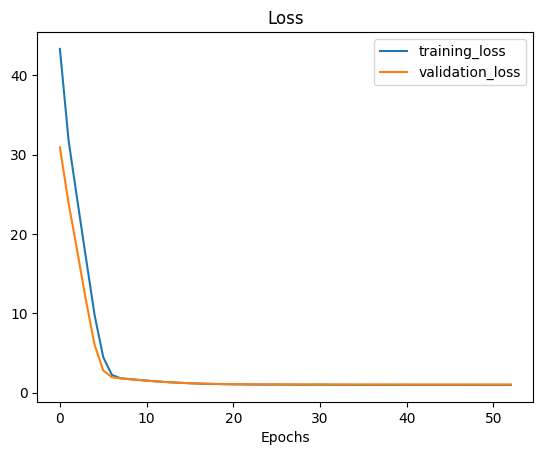

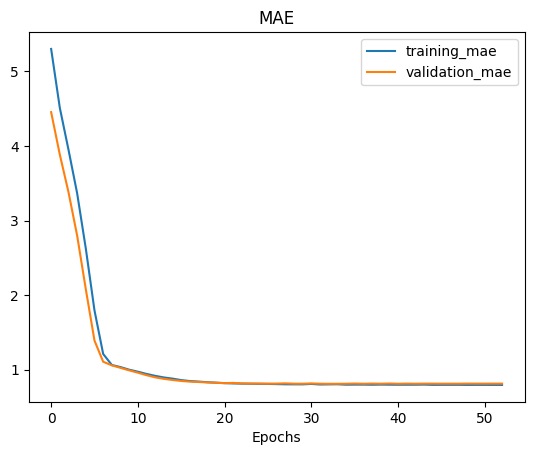

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


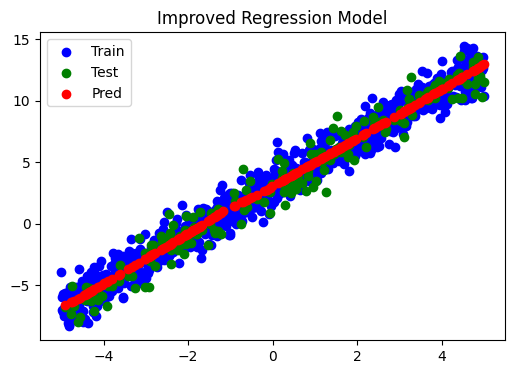

In [7]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Create regression dataset

X = np.linspace(-5, 5, 1000)
y = 2 * X + 3 + np.random.normal(0, 1, len(X))

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build regression model
model = tf.keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(1,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

# Optimization callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3
)

# Train model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

# Plot training curves
def plot_loss_curves(history):

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    mae = history.history["mae"]
    val_mae = history.history["val_mae"]

    epochs = range(len(loss))

    # Loss plot
    plt.figure()
    plt.plot(epochs, loss, label="training_loss")
    plt.plot(epochs, val_loss, label="validation_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # MAE plot
    plt.figure()
    plt.plot(epochs, mae, label="training_mae")
    plt.plot(epochs, val_mae, label="validation_mae")
    plt.title("MAE")
    plt.xlabel("Epochs")
    plt.legend()

    plt.show()

plot_loss_curves(history)

# Prediction scatter plot
y_pred = model.predict(X_test).squeeze()

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, c='b', label='Train')
plt.scatter(X_test,  y_test,  c='g', label='Test')
plt.scatter(X_test,  y_pred,  c='r', label='Pred')
plt.legend()
plt.title("Improved Regression Model")
plt.show()